# Paleta de cores — Presidente 2026 (1º turno) — v2

Preview para aprovação do usuário da paleta revisada em
`config/candidatos.yaml` e das funções `mistura_oklab`/`vencedor_margem`/
`agrupar_outros` de `src/eleicao/cores.py` (ver `docs/DECISOES.md` D-004,
D-013, D-014).

Ajustes desta rodada (pedidos pelo usuário após ver a v1):
1. Faixa de matiz reservada para a mistura PT×PL — nenhum outro candidato
   pode cair nela (ver disco de matiz, seção 2).
2. 4º colocado (Renan Santos) movido para ciano; 5º colocado (Ronaldo
   Caiado) promovido a croma médio (âmbar); 7 candidatos < 1% dos válidos
   agora em cinza (ver seção 1 e Decisão de design #2/#3 no YAML).
3. `vencedor_margem` redesenhado: teto de saturação em 40pp de margem, tom
   neutro acromático em margem=0 (não tingido pelo "vencedor" do empate).
4. Nova função `agrupar_outros` para legendas/gráficos (não usada no mapa).
5. Mapas agora por MUNICÍPIO (antes eram só por UF); mapa de UF mantido,
   só que menor, como referência secundária.

Conteúdo:
1. Amostra de cor de cada um dos 12 candidatos.
2. Disco de matiz (OKLCH polar) com a faixa reservada PT×PL marcada.
3. Gradiente PT↔PL de 0% a 100% (passo 10%), nos dois modos.
4. Tabela de ΔE (OKLab) entre PT/PL e entre os 3º/4º/5º colocados —
   visão normal, protanopia e deuteranopia.
5. Mapas por MUNICÍPIO nos dois modos + simulação de deuteranopia do modo
   mistura; mapa de UF pequeno como referência.

A figura final (tudo acima) é exportada em `docs/img/paleta_preview.png`.

In [1]:
import math

import geobr
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from coloraide import Color

from eleicao import config as cfg
from eleicao.cores import (
    FAIXA_RESERVADA_PT_PL,
    carregar_paleta,
    distancia_oklab,
    mistura_oklab,
    simular_daltonismo,
    vencedor_margem,
)

plt.rcParams["figure.dpi"] = 110

paleta = carregar_paleta()
df_br = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_br.parquet")
df_uf = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_uf.parquet")
df_mun = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_municipio.parquet")
df_mun_totais = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_municipio_totais.parquet")

candidatos = df_br.sort_values("votos", ascending=False).reset_index(drop=True)
candidatos[["nr_candidato", "nm_urna", "partido", "votos", "pct_validos"]]

,nr_candidato,nm_urna,partido,votos,pct_validos
0,22,FLAVIO BOLSONARO,PL,56104503,47.027772
1,13,LULA,PT,53879538,45.162768
2,70,ESCRITOR AUGUSTO CURY,AVANTE,3448569,2.890651
3,14,RENAN SANTOS,MISSÃO,2675887,2.242975
4,55,RONALDO CAIADO,PSD,2605148,2.183680
5,30,ZEMA,NOVO,326488,0.273668
6,80,SAMARA,UP,122911,0.103026
7,16,HERTZ DIAS,PSTU,43103,0.036130
8,27,CLARIANA BARAO,DC,40043,0.033565
9,21,EDMILSON COSTA,PCB,22693,0.019022


## 1. Amostra de cor por candidato

C:\Users\Usuário\AppData\Local\Temp\ipykernel_17564\2157959449.py:7: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))


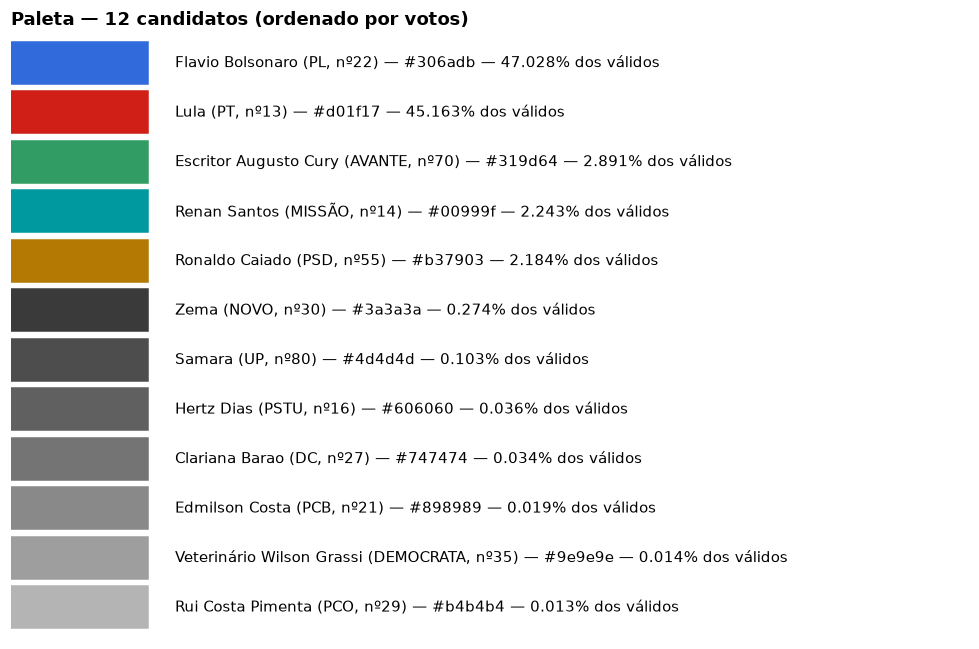

In [2]:
def plotar_swatches(ax, candidatos, paleta, titulo=None):
    n = len(candidatos)
    for i, row in candidatos.iterrows():
        nr = int(row.nr_candidato)
        cor = paleta[nr]
        y = n - 1 - i
        ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))
        rotulo = (
            f"{row.nm_urna.title()} ({row.partido}, nº{nr}) "
            f"— {cor} — {row.pct_validos:.3f}% dos válidos"
        )
        ax.text(1.2, y + 0.42, rotulo, va="center", fontsize=9.5)
    ax.set_xlim(0, 7)
    ax.set_ylim(-0.2, n)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, loc="left", fontsize=12, fontweight="bold")


fig, ax = plt.subplots(figsize=(9, 6))
plotar_swatches(ax, candidatos, paleta, "Paleta — 12 candidatos (ordenado por votos)")
fig.tight_layout()
plt.show()

## 2. Disco de matiz (OKLCH) — faixa reservada PT×PL

Projeção polar: ângulo = matiz (H), raio = croma (C). A área sombreada
marca `FAIXA_RESERVADA_PT_PL` (260°–30°, passando por 360°/0°) — nenhum
candidato (além de PT/PL, que são os dois extremos do gradiente que define
a faixa) deve cair dentro dela. Os 7 candidatos acromáticos (C=0, cinza) não
têm matiz definido — aparecem como uma nota, não como pontos no disco.

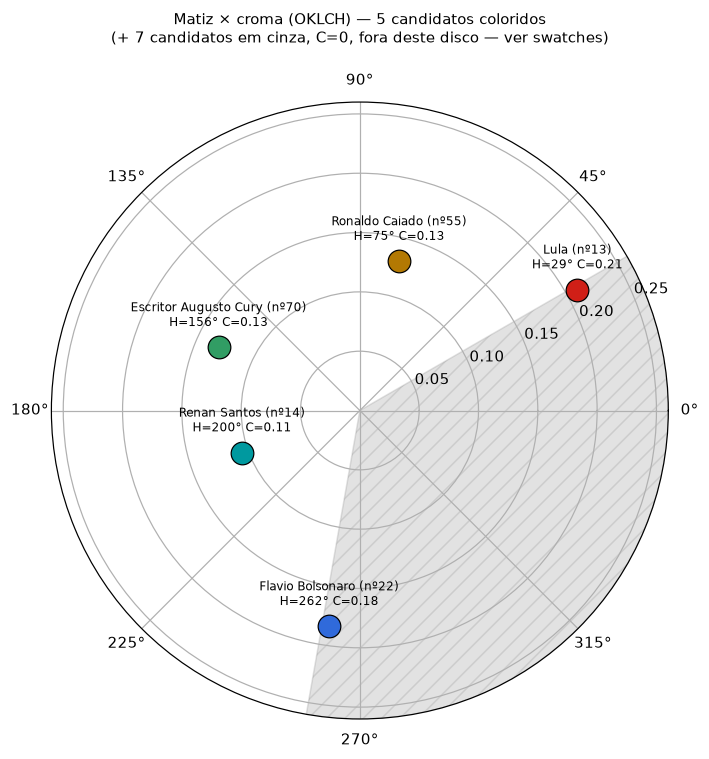

In [3]:
def plotar_disco_matiz(ax):
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    # Faixa reservada: 260 -> 390 (=30+360) em graus, contínua passando por 0/360.
    h0, h1 = FAIXA_RESERVADA_PT_PL
    theta_faixa = np.radians(np.linspace(h0, h1 + 360, 100))
    ax.fill_between(
        theta_faixa, 0, 0.26, color="0.55", alpha=0.25, hatch="//", label="Faixa reservada PT×PL"
    )

    coloridos = {nr: cor for nr, cor in paleta.items() if Color(cor).convert("oklch")[1] > 0.01}
    for nr, cor in coloridos.items():
        _lum, c, h = Color(cor).convert("oklch")[:3]
        nome = candidatos.loc[candidatos["nr_candidato"] == nr, "nm_urna"].iloc[0].title()
        ax.scatter(
            [math.radians(h)], [c], color=cor, s=220, edgecolor="black", linewidth=0.8, zorder=5
        )
        ax.annotate(
            f"{nome} (nº{nr})\nH={h:.0f}° C={c:.2f}",
            (math.radians(h), c),
            textcoords="offset points",
            xytext=(0, 14),
            ha="center",
            fontsize=8,
        )

    ax.set_rmax(0.26)
    ax.set_rticks([0.05, 0.10, 0.15, 0.20, 0.25])
    ax.set_title(
        "Matiz × croma (OKLCH) — 5 candidatos coloridos\n"
        "(+ 7 candidatos em cinza, C=0, fora deste disco — ver swatches)",
        fontsize=10,
        pad=20,
    )


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")
plotar_disco_matiz(ax)
fig.tight_layout()
plt.show()

## 3. Gradiente PT ↔ PL (0% a 100%, passo 10%)

`p` = % dos votos (do subconjunto PT+PL) para o PT (nº13); `100-p` para o PL
(nº22). O modo "vencedor + margem" agora usa a fórmula nova (teto em 40pp,
tom neutro em margem=0).

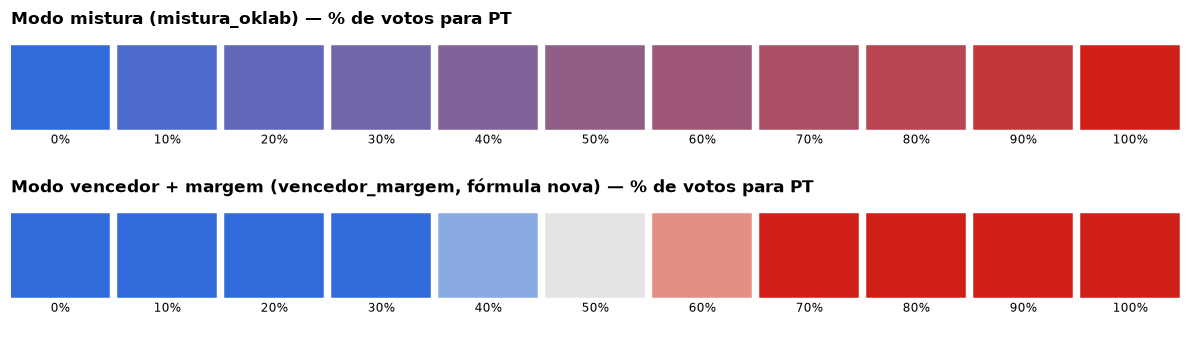

In [4]:
passos = list(range(0, 101, 10))

gradiente_mistura = []
gradiente_vencedor = []
for p in passos:
    votos = {13: p, 22: 100 - p}
    gradiente_mistura.append(mistura_oklab(votos, paleta))
    gradiente_vencedor.append(vencedor_margem(votos, paleta))


def plotar_gradiente(ax, cores, passos, titulo):
    n = len(cores)
    for i, (cor, p) in enumerate(zip(cores, passos, strict=True)):
        ax.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=cor))
        ax.text(i + 0.46, -0.18, f"{p}%", ha="center", fontsize=8)
    ax.set_xlim(0, n)
    ax.set_ylim(-0.4, 1.15)
    ax.axis("off")
    ax.set_title(titulo, loc="left", fontsize=11, fontweight="bold")


titulo_mistura = "Modo mistura (mistura_oklab) — % de votos para PT"
titulo_vencedor = "Modo vencedor + margem (vencedor_margem, fórmula nova) — % de votos para PT"

fig, axes = plt.subplots(2, 1, figsize=(11, 3.2))
plotar_gradiente(axes[0], gradiente_mistura, passos, titulo_mistura)
plotar_gradiente(axes[1], gradiente_vencedor, passos, titulo_vencedor)
fig.tight_layout()
plt.show()

## 4. ΔE (OKLab) — PT×PL e 3º/4º/5º colocados

Distância perceptual (`distancia_oklab`, método `"ok"` do coloraide) em
visão normal e simulada (protanopia/deuteranopia). Limiar adotado: ΔE ≥ 0,10
é "facilmente distinguível" (consistente com a skill `dataviz` do projeto,
que recomenda ΔE ≥ 8 sob CVD e ≥ 15 em visão normal numa escala ×100).

In [5]:
nomes_tabela = {13: "PT", 22: "PL", 70: "Cury (3º)", 14: "Renan (4º)", 55: "Caiado (5º)"}
pares_tabela = [
    (13, 22),
    (70, 14),
    (70, 55),
    (14, 55),
    (70, 13),
    (70, 22),
    (14, 13),
    (14, 22),
    (55, 13),
    (55, 22),
]

linhas_tabela = []
for nr_a, nr_b in pares_tabela:
    cor_a, cor_b = paleta[nr_a], paleta[nr_b]
    de_normal = distancia_oklab(cor_a, cor_b)
    de_protan = distancia_oklab(
        simular_daltonismo(cor_a, "protan"), simular_daltonismo(cor_b, "protan")
    )
    de_deutan = distancia_oklab(
        simular_daltonismo(cor_a, "deutan"), simular_daltonismo(cor_b, "deutan")
    )
    linhas_tabela.append(
        {
            "par": f"{nomes_tabela[nr_a]} × {nomes_tabela[nr_b]}",
            "ΔE normal": round(de_normal, 3),
            "ΔE protanopia": round(de_protan, 3),
            "ΔE deuteranopia": round(de_deutan, 3),
            "passa (≥0.10) nos 3?": bool(
                de_normal >= 0.10 and de_protan >= 0.10 and de_deutan >= 0.10
            ),
        }
    )

tabela_delta_e = pd.DataFrame(linhas_tabela)
tabela_delta_e

,par,ΔE normal,ΔE protanopia,ΔE deuteranopia,passa (≥0.10) nos 3?
0,PT × PL,0.353,0.289,0.309,True
1,Cury (3º) × Renan (4º),0.091,0.088,0.091,False
2,Cury (3º) × Caiado (5º),0.169,0.094,0.089,False
3,Renan (4º) × Caiado (5º),0.209,0.165,0.179,True
4,Cury (3º) × PT,0.314,0.235,0.094,False
5,Cury (3º) × PL,0.262,0.259,0.244,True
6,Renan (4º) × PT,0.322,0.257,0.176,True
7,Renan (4º) × PL,0.178,0.181,0.161,True
8,Caiado (5º) × PT,0.168,0.169,0.063,False
9,Caiado (5º) × PL,0.321,0.301,0.330,True


## 5. Mapas por município — dois modos + simulação de deuteranopia

Usa `presidente_t1_municipio.parquet` (votos por candidato) +
`presidente_t1_municipio_totais.parquet` (só para o `cd_mun_ibge`, que o
parquet de candidatos não traz) + `geobr.read_municipality(year=2024)`
(mesmo padrão de `scripts/diagnostico_join_ibge.py`). `simplified=True`
(padrão do `geobr`) já é leve o suficiente para os 5571 municípios sem
`.simplify()` adicional — não aplicamos simplificação extra.

In [6]:
cd_ibge_por_mun = df_mun_totais.set_index(["uf", "cd_mun_tse"])["cd_mun_ibge"]

df_mun_br = df_mun[df_mun["uf"] != "zz"].copy()
df_mun_br["cd_mun_ibge"] = df_mun_br.set_index(["uf", "cd_mun_tse"]).index.map(cd_ibge_por_mun)
df_mun_br = df_mun_br.dropna(subset=["cd_mun_ibge"])

cor_mistura_por_mun = {}
cor_vencedor_por_mun = {}
for cd_ibge, grupo in df_mun_br.groupby("cd_mun_ibge"):
    votos = dict(zip(grupo["nr_candidato"].astype(int), grupo["votos"].astype(int), strict=True))
    cor_mistura_por_mun[cd_ibge] = mistura_oklab(votos, paleta)
    cor_vencedor_por_mun[cd_ibge] = vencedor_margem(votos, paleta)

n_coloridos = len(cor_mistura_por_mun)
n_com_ibge = df_mun_br["cd_mun_ibge"].nunique()
print(f"{n_coloridos} municípios coloridos (de {n_com_ibge} com cd_mun_ibge)")

gdf_mun = geobr.read_municipality(year=2024, show_progress=False)
gdf_mun["cd_mun_ibge"] = gdf_mun["code_muni"].astype("Int64").astype(str)
gdf_mun["cor_mistura"] = gdf_mun["cd_mun_ibge"].map(cor_mistura_por_mun)
gdf_mun["cor_vencedor"] = gdf_mun["cd_mun_ibge"].map(cor_vencedor_por_mun)
gdf_mun["cor_mistura_deutan"] = gdf_mun["cor_mistura"].apply(
    lambda h: simular_daltonismo(h, "deutan") if isinstance(h, str) else h
)
print(f"municípios sem cor (sem par no TSE): {gdf_mun['cor_mistura'].isna().sum()}")

5571 municípios coloridos (de 5571 com cd_mun_ibge)


municípios sem cor (sem par no TSE): 0


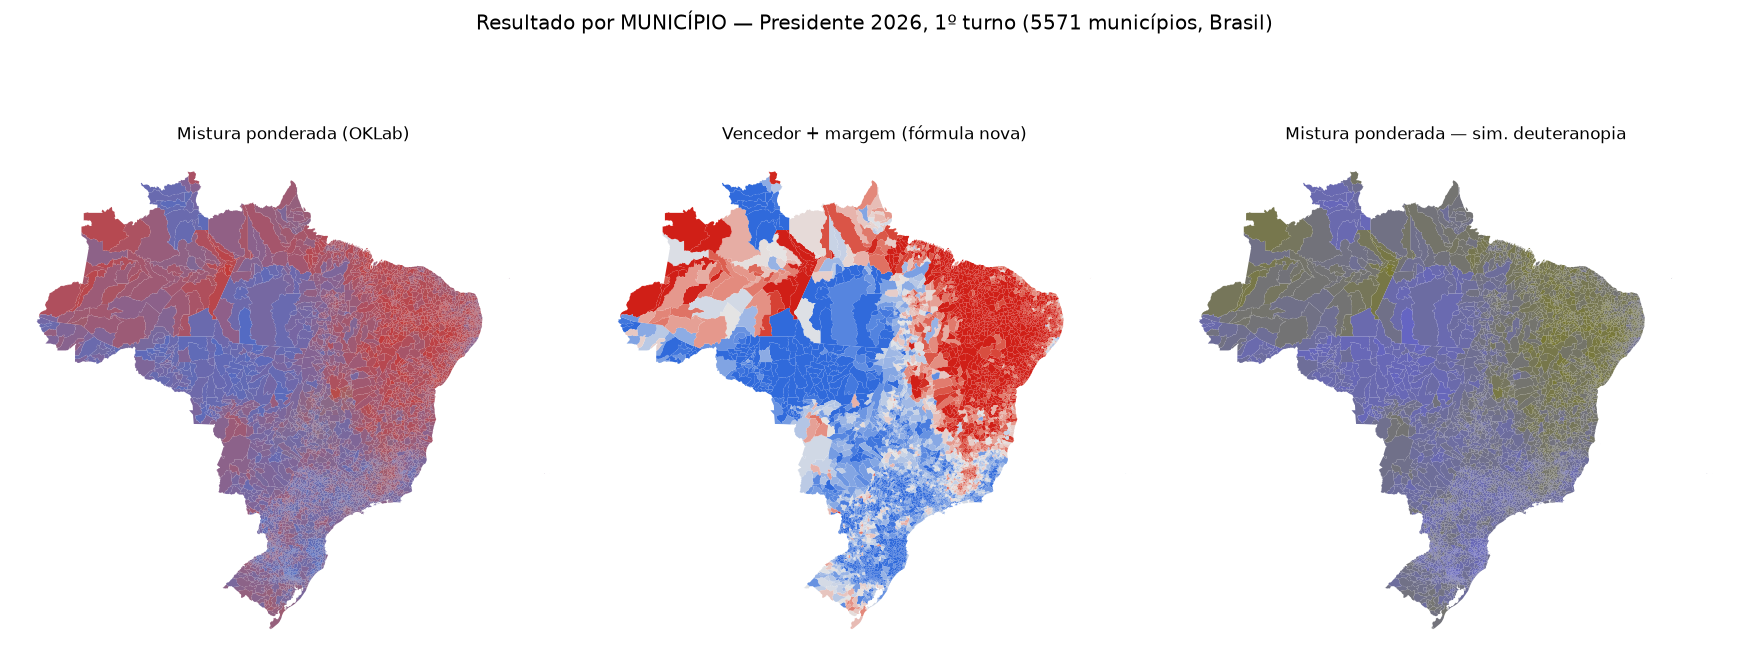

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
gdf_mun.plot(ax=axes[0], color=gdf_mun["cor_mistura"], linewidth=0)
axes[0].set_title("Mistura ponderada (OKLab)", fontsize=11)
axes[0].axis("off")
gdf_mun.plot(ax=axes[1], color=gdf_mun["cor_vencedor"], linewidth=0)
axes[1].set_title("Vencedor + margem (fórmula nova)", fontsize=11)
axes[1].axis("off")
gdf_mun.plot(ax=axes[2], color=gdf_mun["cor_mistura_deutan"], linewidth=0)
axes[2].set_title("Mistura ponderada — sim. deuteranopia", fontsize=11)
axes[2].axis("off")
fig.suptitle(
    "Resultado por MUNICÍPIO — Presidente 2026, 1º turno (5571 municípios, Brasil)", fontsize=13
)
fig.tight_layout()
plt.show()

## 6. Mapa de UF (referência secundária, menor)

Mantido da v1 só como referência rápida de padrão regional — o mapa
"principal" agora é o municipal acima.

states_2020_simplified.parquet:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 53.3MB/s]

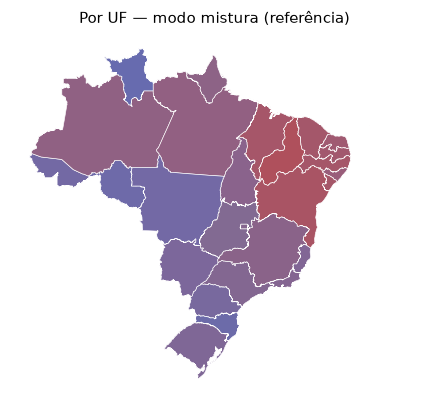

In [8]:
gdf_uf = geobr.read_state(year=2020)
gdf_uf["uf"] = gdf_uf["abbrev_state"].str.lower()

df_uf_validos = df_uf[df_uf["uf"] != "zz"]
cor_mistura_por_uf = {}
for uf, grupo in df_uf_validos.groupby("uf"):
    votos = dict(zip(grupo["nr_candidato"].astype(int), grupo["votos"].astype(int), strict=True))
    cor_mistura_por_uf[uf] = mistura_oklab(votos, paleta)
gdf_uf["cor_mistura"] = gdf_uf["uf"].map(cor_mistura_por_uf)

fig, ax = plt.subplots(figsize=(4, 4))
gdf_uf.plot(ax=ax, color=gdf_uf["cor_mistura"], edgecolor="white", linewidth=0.4)
ax.set_title("Por UF — modo mistura (referência)", fontsize=10)
ax.axis("off")
fig.tight_layout()
plt.show()

## 7. Figura final (exportada em `docs/img/paleta_preview.png`)

Combina os elementos acima em uma única imagem.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_17564\2157959449.py:7: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))


Salvo em C:\Users\Usuário\Pessoal\analise_eleicao_2026\docs\img\paleta_preview.png


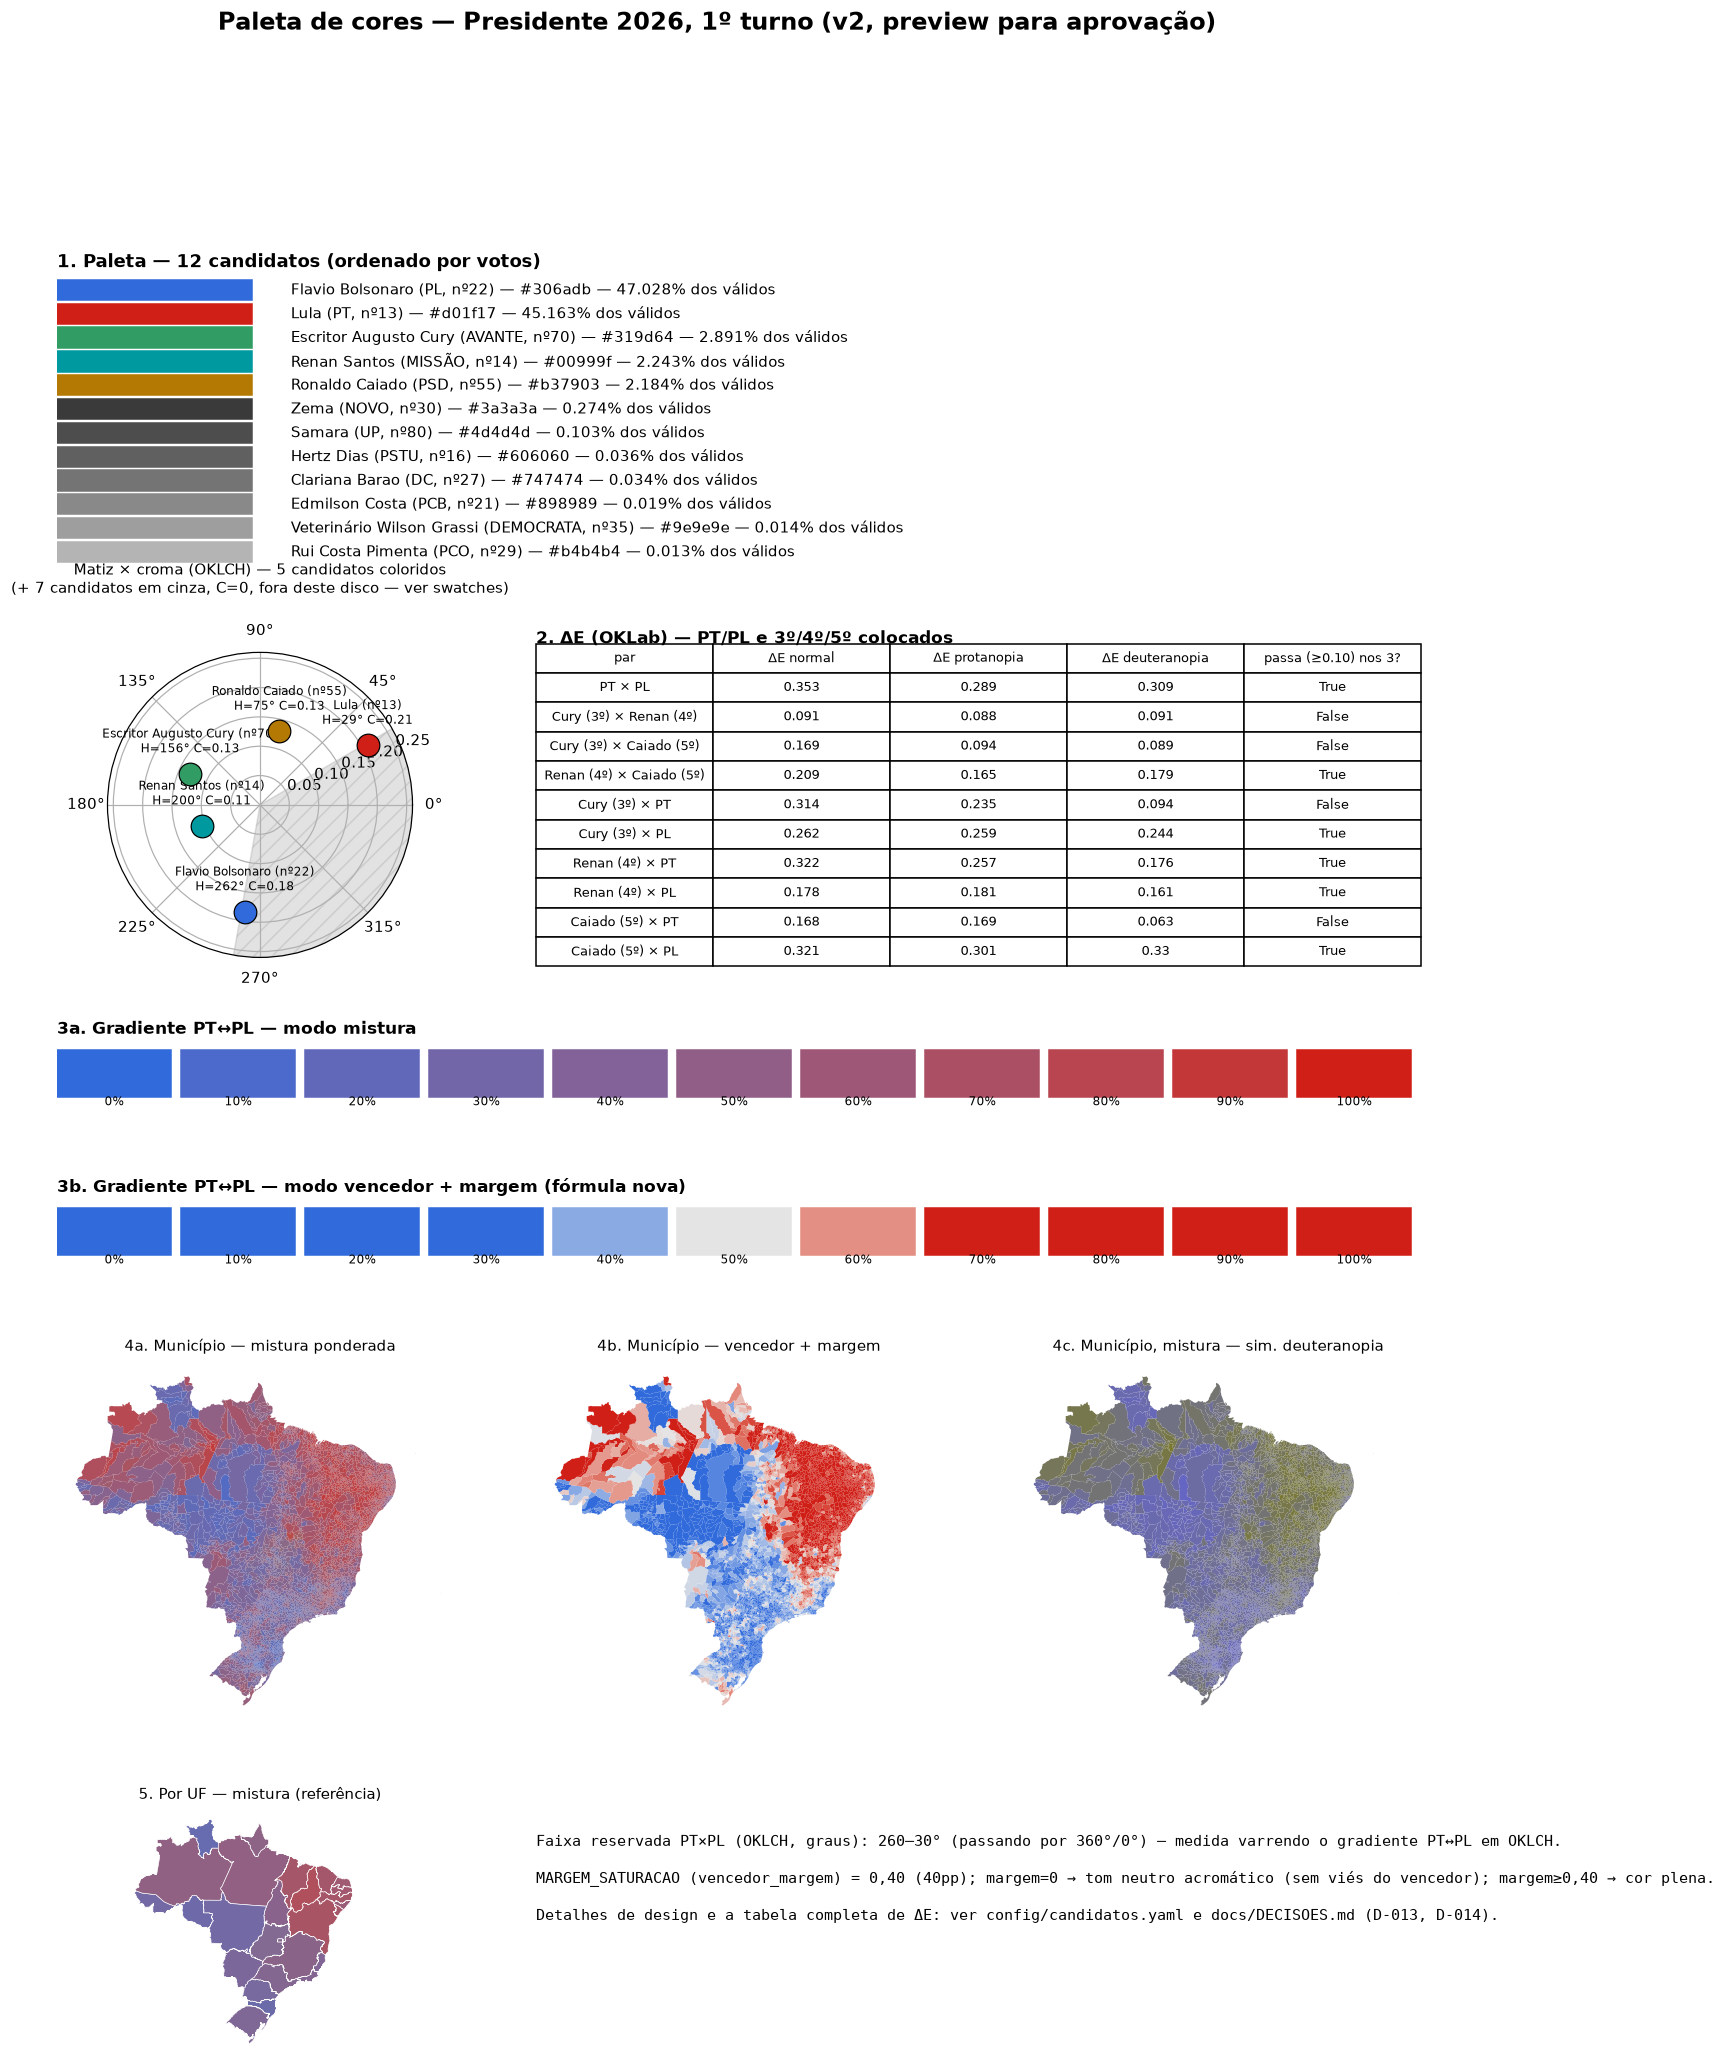

In [9]:
fig = plt.figure(figsize=(16, 21))
gs = gridspec.GridSpec(6, 3, height_ratios=[2.0, 2.1, 0.5, 0.5, 2.5, 1.7], hspace=0.38, wspace=0.18)

ax_swatches = fig.add_subplot(gs[0, :])
plotar_swatches(ax_swatches, candidatos, paleta, "1. Paleta — 12 candidatos (ordenado por votos)")

ax_disco = fig.add_subplot(gs[1, 0], projection="polar")
plotar_disco_matiz(ax_disco)

ax_tabela = fig.add_subplot(gs[1, 1:])
ax_tabela.axis("off")
titulo_tabela = "2. ΔE (OKLab) — PT/PL e 3º/4º/5º colocados"
ax_tabela.set_title(titulo_tabela, loc="left", fontsize=11, fontweight="bold")
tabela_mpl = ax_tabela.table(
    cellText=tabela_delta_e.values,
    colLabels=tabela_delta_e.columns,
    loc="center",
    cellLoc="center",
)
tabela_mpl.auto_set_font_size(False)
tabela_mpl.set_fontsize(8.5)
tabela_mpl.scale(1, 1.6)

ax_grad1 = fig.add_subplot(gs[2, :])
plotar_gradiente(ax_grad1, gradiente_mistura, passos, "3a. Gradiente PT\u2194PL — modo mistura")

ax_grad2 = fig.add_subplot(gs[3, :])
titulo_grad2_fig = "3b. Gradiente PT\u2194PL — modo vencedor + margem (fórmula nova)"
plotar_gradiente(ax_grad2, gradiente_vencedor, passos, titulo_grad2_fig)

ax_m1 = fig.add_subplot(gs[4, 0])
gdf_mun.plot(ax=ax_m1, color=gdf_mun["cor_mistura"], linewidth=0)
ax_m1.set_title("4a. Município — mistura ponderada", fontsize=10)
ax_m1.axis("off")

ax_m2 = fig.add_subplot(gs[4, 1])
gdf_mun.plot(ax=ax_m2, color=gdf_mun["cor_vencedor"], linewidth=0)
ax_m2.set_title("4b. Município — vencedor + margem", fontsize=10)
ax_m2.axis("off")

ax_m3 = fig.add_subplot(gs[4, 2])
gdf_mun.plot(ax=ax_m3, color=gdf_mun["cor_mistura_deutan"], linewidth=0)
ax_m3.set_title("4c. Município, mistura — sim. deuteranopia", fontsize=10)
ax_m3.axis("off")

ax_uf = fig.add_subplot(gs[5, 0])
gdf_uf.plot(ax=ax_uf, color=gdf_uf["cor_mistura"], edgecolor="white", linewidth=0.4)
ax_uf.set_title("5. Por UF — mistura (referência)", fontsize=10)
ax_uf.axis("off")

ax_texto = fig.add_subplot(gs[5, 1:])
ax_texto.axis("off")
linha_faixa = (
    f"Faixa reservada PT\u00d7PL (OKLCH, graus): "
    f"{FAIXA_RESERVADA_PT_PL[0]:.0f}\u2013{FAIXA_RESERVADA_PT_PL[1]:.0f}\u00b0 "
    f"(passando por 360\u00b0/0\u00b0) \u2014 medida varrendo o gradiente PT\u2194PL em OKLCH."
)
linha_margem = (
    "MARGEM_SATURACAO (vencedor_margem) = 0,40 (40pp); margem=0 \u2192 tom neutro "
    "acrom\u00e1tico (sem vi\u00e9s do vencedor); margem\u22650,40 \u2192 cor plena."
)
linha_doc = (
    "Detalhes de design e a tabela completa de \u0394E: ver "
    "config/candidatos.yaml e docs/DECISOES.md (D-013, D-014)."
)
ax_texto.text(
    0,
    0.9,
    "\n\n".join([linha_faixa, linha_margem, linha_doc]),
    fontsize=10,
    va="top",
    family="monospace",
)

fig.suptitle(
    "Paleta de cores — Presidente 2026, 1º turno (v2, preview para aprovação)",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

caminho_png = cfg.RAIZ / "docs" / "img" / "paleta_preview.png"
caminho_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(caminho_png, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo em {caminho_png}")
plt.show()